In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
import warnings
import pickle
from matplotlib.lines import Line2D
import matplotlib.font_manager as fm
import scanpy as sc
from scipy.spatial.distance import pdist, squareform, cdist
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.neighbors import NearestNeighbors
import matplotlib.patheffects as pe
import scvelo as scv
from matplotlib.patches import Rectangle
from scipy.stats import spearmanr, linregress,  mannwhitneyu, kstest
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import seaborn as sns
from math import gamma, pi
from utils import (datenum_to_datetime, datetime_to_datenum)
import matplotlib.colors as mcolors
import os

fontpath='./data/Arial.ttf'
fm.fontManager.addfont(fontpath)
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'font.size': 10,
    'lines.linewidth': 1.5,
    'axes.spines.top': True,
    'axes.spines.right': True,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.major.size': 5,
    'ytick.major.size': 5
})
plt.rcParams['font.family'] = 'Arial'
# Suppress warnings
warnings.filterwarnings('ignore')


# Load Data

In [21]:
region = "Canada"
ind_wt=0
ind_ba5=6
ind_ba1=3
ind_XBB=8
deltat=7
with open('./data/model_data.pkl', 'rb') as f:
    data = pickle.load(f)
P=data['P']
covariate_time=data['covaraite_time']
time_obs=data['time_obs']
s=data['s']
phi_array=data['phi']
vac_array=data['vac']
lambda_=data['lambda']
r=data['r']
I_vac=data['I_vac']
X=data['x_obs']

In [22]:
adata = sc.read_h5ad("./data/antigenic_adata_clustered.h5ad")
distance_matrix_df = pd.read_parquet('./data/filtered_mutant_ad_mix.parquet')
distance_matrix=distance_matrix_df.values
csv_path=f'./data//mutant_counts_by_date_{region}.csv'
seqs_count_df = pd.read_csv(csv_path, header=0, index_col=None)
cluster_codes = adata.obs['leiden_reordered'].astype(int).to_numpy()
n_obs = adata.n_obs
n_cluster = adata.obs['leiden_reordered'].nunique()
one_hot = np.zeros((n_obs, n_cluster), dtype=int)
for i, code in enumerate(cluster_codes):
    one_hot[i, code] = 1
cluster_sizes = one_hot.sum(axis=0)
avg_dist = (distance_matrix @ one_hot) / cluster_sizes   
avg_dist_vac= avg_dist[:, [ind_wt, ind_wt, ind_ba5, ind_XBB]]  # Indices adjusted for 0-based
# For bivalent vaccine, use minimum distance principle
avg_dist_vac[:, 2] = np.minimum(avg_dist_vac[:, 0], avg_dist_vac[:, 2])
ace2_binding = adata.obs["ace2_binding"].to_numpy()
# Extract sequence count data
seq_count = seqs_count_df.iloc[:, 1:].to_numpy(copy=False)
count_time = pd.to_datetime(seqs_count_df.iloc[:, 0]).apply(lambda x: datetime_to_datenum(x))
seq_x_obs_ave = []

# Calculate sequence frequencies at each time point
for i, t in enumerate(time_obs):
    # 14-day window for more stable estimates
    ind_ave = np.where((count_time > t-7) & (count_time <= t))[0]
    if len(ind_ave) > 0:
        seq_count_obs_ave_i = seq_count [ind_ave, :].sum(axis=0)
        seq_x_obs_ave.append(seq_count_obs_ave_i / seq_count_obs_ave_i.sum())
    else:
        seq_x_obs_ave.append(np.zeros(seq_count.shape[1]))
# Convert to arrays
seq_x_obs_ave = np.array(seq_x_obs_ave)
seq_inf_num=phi_array[:, None]*seq_x_obs_ave* P/1000000 #T*S

# Sequence-level fitness

In [23]:
T=time_obs.shape[0]
idx = np.arange(T)
diff = np.subtract.outer(idx, idx)
W=np.tril(np.exp(-diff * deltat * lambda_))   
I_seq=W@seq_inf_num #T*n_obs
C = np.exp(-distance_matrix / r) #n_obs*n_obs
S = C @ I_seq.T  #n_obs * T
C_vac = np.exp(-avg_dist_vac / r) #n_obs * n_vac
S_vac = C_vac @ I_vac.T #n_obs * T
F = - s[1] * S / P - s[2] * S_vac / P #n_obs * T
f = F - (F * seq_x_obs_ave.T ).sum(axis=0, keepdims=True)

# Parmater perturbation

In [24]:

parameters = [
    (r'$s_{inf}$',    lambda f: (s[1] * f, s[2],       lambda_,     r)),
    (r'$s_{vac}$',    lambda f: (s[1],     s[2] * f,   lambda_,     r)),
    (r'$\lambda$',lambda f: (s[1],     s[2],       lambda_ * f,r)),
    ('r',      lambda f: (s[1],     s[2],       lambda_,     r * f))
]

factors = [(0.5, '(-50%)'), (1.5, '(+50%)')]

group_names = []
f_list = []  

for param_name, param_func in parameters:
    for factor, label in factors:
        group_names.append(f"{param_name}{label}")

        s1_new, s2_new, lambda_new, r_new = param_func(factor)

        W = np.tril(np.exp(-diff * deltat * lambda_new))
        I_seq = W @ seq_inf_num
        S = np.exp(-distance_matrix / r_new) @ I_seq.T
        S_vac = np.exp(-avg_dist_vac / r_new) @ I_vac.T

        F = - s1_new * S / P - s2_new * S_vac / P
        f_ = F - (F * seq_x_obs_ave.T).sum(axis=0, keepdims=True)

        f_list.append(f_)

        print(f"{param_name} {label}: computed")
# shape: (n_obs, T, 8)
f_all = np.stack(f_list, axis=-1)


$s_{inf}$ (-50%): computed
$s_{inf}$ (+50%): computed
$s_{vac}$ (-50%): computed
$s_{vac}$ (+50%): computed
$\lambda$ (-50%): computed
$\lambda$ (+50%): computed
r (-50%): computed
r (+50%): computed


# Perturbed antigenic velocity

In [25]:
# --- Classical MDS ---
def classical_mds(D, n_components=2):
    D = np.asarray(D, dtype=float)
    n = D.shape[0]
    np.fill_diagonal(D, 0.0)
    D2 = D**2
    J = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * (J @ D2 @ J)
    evals, evecs = np.linalg.eigh(B)
    order = np.argsort(evals)[::-1]
    evals, evecs = evals[order], evecs[:, order]
    pos = np.clip(evals[:n_components], 0.0, None)
    X = evecs[:, :n_components] * np.sqrt(pos)
    return X, evecs, evals

def mds_out_of_sample(D11, D21, V, Lambda, n_components=2):
    """
    Gower/Nyström out-of-sample extension.
    Inputs:
      D11: (N x N) old-old distances
      D21: (M x N) new-old distances
      V:   (N x P) eigenvectors from old B11
      Lambda: (P,) positive eigenvalues from old B11
    Returns:
      Y: (M x P) coordinates for new points
    """
    N = D11.shape[0]
    M = D21.shape[0]
    Delta11 = D11**2
    Delta21 = D21**2
    V=V[:, :n_components]
    Lambda=Lambda[:n_components]
    delta = (Delta11 @ np.ones((N,1)) / N).ravel()          # (N,)
    mu = (np.ones((1,N)) @ Delta11 @ np.ones((N,1)) / (N**2)).item()  # scalar
    r = (Delta21 @ np.ones((N,1)) / N).ravel()              # (M,)

    B21 = -0.5 * (Delta21 - r[:,None] - delta[None,:] + mu)

    Y = B21 @ (V / np.sqrt(Lambda))   # same as B21 @ V @ diag(Lambda^{-1/2})
    return Y



def pca_pred_direction_ood(t_ind, t_span_past, t_span, seq_x_obs_ave, distance_matrix, f_t, f_all, X_thre=0.0005, dim=3):
    
    col = seq_x_obs_ave.T[:, t_ind]                      # (N,)
    idx_now = np.where(col > X_thre)[0] # con_current seqs
    sub_X_t_past = seq_x_obs_ave.T[:, t_ind-t_span_past:t_ind]     # (N, t_span)
    idx_past = np.where((sub_X_t_past > X_thre).any(axis=1))[0] # seqs for classical MDS
    sub_X_t_future = seq_x_obs_ave.T[:, t_ind+1:t_ind+t_span]     # (N, t_span)
    idx_future = np.where((sub_X_t_future > X_thre).any(axis=1))[0] 
    idx_new = np.setdiff1d(idx_future, idx_past) # seqs for out of sample MDS
    idx_all = np.concatenate([idx_past, idx_new])
    sub_X_t_all = seq_x_obs_ave.T[idx_all, t_ind-t_span_past:t_ind+t_span]     # (N, t_span)
    mask_now = np.isin(idx_all, idx_now)
    D11 = distance_matrix[np.ix_(idx_past , idx_past)]
    D21 = distance_matrix[np.ix_(idx_new , idx_past)]
    D22 = distance_matrix[np.ix_(idx_new , idx_new)]
    # --- MDS ---
    X_past, evecs, evals = classical_mds(D11, n_components=dim)
    X_new=mds_out_of_sample(D11, D21, evecs, evals, n_components=dim)
    X_all=np.concatenate([X_past, X_new], axis=0)
    tot = evals[evals>0].sum()
    pc_ratio = (evals[0:dim] / tot)
    centroids = np.zeros((t_span, dim))
    for k in range(t_span):
        w = sub_X_t_all[:, t_span_past+k].astype(float)
        c = (X_all * w[:, None]).sum(axis=0) / w.sum()
        centroids[k]=c

    #---predicted and emprical direction---
    c_t = centroids[0]
    g_vec_emp=centroids[1:]-c_t
    g_norm_emp = np.linalg.norm(g_vec_emp, axis=1, keepdims=True)
    g_hat_emp = np.where(g_norm_emp == 0, 0, g_vec_emp / g_norm_emp)
    diff = X_all[mask_now,:] - c_t


    w_dir = f_t[idx_all[mask_now], t_ind].astype(float)*seq_x_obs_ave.T[idx_all[mask_now], t_ind].astype(float)
    g_vec = (diff* w_dir[:, None]).sum(axis=0)
    g_norm = np.linalg.norm(g_vec)
    g_hat = g_vec / g_norm
    cos_sim=g_hat_emp @ g_hat
    theta_e=np.degrees(np.arccos(cos_sim))

    w_dir_all = f_all[idx_all[mask_now], t_ind] * seq_x_obs_ave.T[idx_all[mask_now], t_ind][:, None]
    g_vec_all = (diff[:, :, None] * w_dir_all[:, None, :]).sum(axis=0)
    g_norm_all = np.linalg.norm(g_vec_all, axis=0)
    g_hat_all = np.divide(g_vec_all, g_norm_all[None, :], out=np.zeros_like(g_vec_all), where=g_norm_all[None, :] != 0)
    theta_e_all = np.degrees(np.arccos(np.clip(g_hat_emp @ g_hat_all, -1, 1)))


    return pc_ratio, centroids, g_norm, g_norm_emp, theta_e ,g_norm_all,theta_e_all

t_span = 9
t_span_past = 5
t_start=50
t_end=250
dim=3
T_total=t_end-t_start+1
Theta = np.full((T_total, t_span - 1), np.nan) 
Theta_all = np.full((T_total, t_span - 1 ,8), np.nan) 
G_norm = np.full((T_total, 1), np.nan) 
G_norm_all = np.full((T_total, 8), np.nan) 
G_norm_emp= np.full((T_total, t_span - 1), np.nan) 
pc_ratios = np.full((T_total, dim), np.nan) 
c_ad=8.0706 #ratio between dms and assay based antigenic distance
for i, t_ind in enumerate(range(t_start, t_end + 1)):
    out = pca_pred_direction_ood(t_ind, t_span_past, t_span, seq_x_obs_ave, distance_matrix*c_ad, f ,f_all,X_thre=0.0003, dim=dim)
    theta_e = out[-3]  
    theta_e_all= out[-1]
    g_norm_emp= out[-4]                   
    g_norm= out[-5] 
    g_norm_all= out[-2] 
    Theta[i, :] = theta_e
    Theta_all[i,:,:]=theta_e_all
    G_norm_emp[i, :] = g_norm_emp.T
    G_norm[i]= g_norm
    G_norm_all[i]= g_norm_all
    pc_ratios[i]=out[0]
    print(i)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200


In [26]:
G_emp=G_norm_emp[:, 0].ravel()/7
G=G_norm.ravel()
def get_phase_mask(v, v_thr, a_thr,  a_thr_down, min_len=2):
    v = np.asarray(v, dtype=float)
    T = v.size
    if T == 0: 
        return np.array([], int), np.array([], int)

    a = np.empty_like(v); 
    a[0] = 0.0; a[1:] = np.diff(np.log(v))
    cond_up_relax   =  (a >  0.01) & (v > v_thr)
    cond_up   = (a >  a_thr) & (v > v_thr)
    cond_down = (a < a_thr_down)
    cond_down = (a < a_thr_down)

    two_up_relax = np.zeros(T, bool);   
    two_up_relax[1:] = cond_up_relax[1:]   & cond_up_relax[:-1]
    mask = np.zeros(T, int)
    state = 0; adp_start = []

    for t in range(T):
        if state == 0:
            if (cond_up[t]) :
                state = 1; adp_start.append(t)
        elif state == 1:
            if cond_down[t]:
                state = 2
        else:  
            if (two_up_relax[t]) or (cond_up[t]) :
                state = 1; adp_start.append(t)
            elif v[t] < v_thr:
                state = 0
        mask[t] = state

    i = 0
    adp_start = np.asarray(adp_start, int)
    while i < T:
        if mask[i] != 1:
            i += 1; continue
        j = i
        while j < T and mask[j] == 1: j += 1            
        if j - i < min_len:                              
            k = j
            while k < T and mask[k] == 2: k += 1        
            prev = mask[i-1] if i > 0 else 0
            mask[i:k] = prev
            if adp_start.size:
                keep = (adp_start < i) | (adp_start >= k)
                adp_start = adp_start[keep]
            i = k
        else:
            i = j

    return mask, adp_start
v_thr = 0.00125
a_thr_up = 0.1
a_thr_down = 0
phase_mask,adp_start =get_phase_mask(G, v_thr,a_thr_up,a_thr_down, min_len=3)

findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Ari

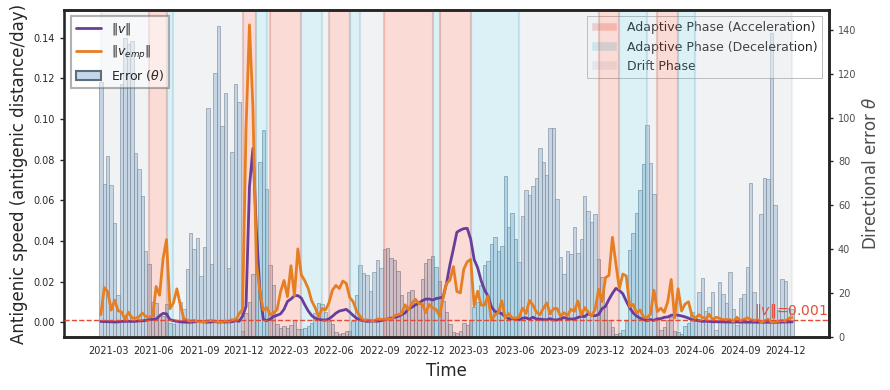

In [ ]:
# ---- colors ----
color_theta = "#C4D6E8"
edge_theta  = "#5A6E7D"
color_model = "#6A3D9A"
color_emp   = "#E67E22"
color_acc   = "#E64B35"
color_dec   = "#4DBBD5"
color_drift = "#B8C2CC"
color_thr   = "#E64B35"
dates_timeline = [datenum_to_datetime(int(t)) for t in time_obs[t_start:t_end+1]]
dates_timeline = pd.to_datetime(dates_timeline)
def color_phase_background(ax, dates, mask, alpha=0.20, zorder=0):
    T = len(mask)
    current = mask[0]
    start = 0
    for i in range(1, T):
        if mask[i] != current or i == T - 1:
            end = i if mask[i] != current else i + 1
            if current == 0:
                c = color_drift
            elif current == 1:
                c = color_acc
            elif current == 2:
                c = color_dec
            else:
                c = "white"
            x0 = dates[start]
            x1 = dates[end] if end < len(dates) else dates[-1]
            ax.axvspan(x0, x1, color=c, alpha=alpha, zorder=zorder)
            current = mask[i]
            start = i

# =========================
#   MAIN PLOT
# =========================
fig, ax2 = plt.subplots(figsize=(9, 4))   # left: G, G_emp
ax1 = ax2.twinx()                         # right: Theta



# background (lowest)
color_phase_background(ax2, dates_timeline, phase_mask, alpha=0.20, zorder=0)

# right axis bar (above background)
bar = ax1.bar(
    dates_timeline, Theta[:, -1],
    color=color_theta, alpha=0.9, label=r"Error ($\theta$)",
    width=np.timedelta64(7, 'D'),
    edgecolor=edge_theta, linewidth=0.4, zorder=2
)

# left axis lines (top)
line_model, = ax2.plot(
    dates_timeline, G,
    color=color_model, linewidth=2, 
    label=r"$\|v\|$ ", zorder=3
)
line_emp, = ax2.plot(
    dates_timeline, G_emp,
    color=color_emp, linewidth=2, 
    label=r"$\|v_{emp}\|$", zorder=3
)

# threshold line (left)
ax2.axhline(y=v_thr, color=color_thr, linestyle="--", linewidth=1, zorder=3)
ax2.text(dates_timeline[-12], v_thr, fr"$\| v \|$={v_thr:.3f}",
         va="bottom", ha="left", color=color_thr, fontsize=10, zorder=3)

# labels
ax2.set_xlabel("Time", fontsize=12)
ax2.set_ylabel(r"Antigenic speed (antigenic distance/day)", fontsize=12)
ax1.set_ylabel(r"Directional error $\theta$", color="0.3", fontsize=12)
ax1.tick_params(axis='y', labelcolor="0.3")

# enforce sides (no double ticks)
ax2.tick_params(axis='y', left=True, right=False)
ax1.tick_params(axis='y', right=True, left=False, labelright=True, labelleft=False)
ax1.spines['left'].set_visible(False)

# x ticks (set once on ax2)
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax2.tick_params(axis="x", which="major", width=1, length=3.2, labelsize=7)
ax2.tick_params(axis="y", which="major", width=1, length=3.2, labelsize=7)
ax1.tick_params(axis="y", which="major", width=1, length=3.2, labelsize=7)

ax2.grid(False); ax1.grid(False)

# zorder + transparent top axis background (so bars don't get covered)
ax2.set_zorder(3)
ax1.set_zorder(2)
ax2.patch.set_visible(False)

# legends
phase_handles = [
    Patch(facecolor=color_acc,   alpha=0.25, label="Adaptive Phase (Acceleration)"),
    Patch(facecolor=color_dec,   alpha=0.25, label="Adaptive Phase (Deceleration)"),
    Patch(facecolor=color_drift, alpha=0.25, label="Drift Phase"),
]
leg_phase = ax1.legend(handles=phase_handles, loc="upper right",
                       frameon=True, framealpha=0.5, edgecolor='0.4',
                       fancybox=False, fontsize=9)
leg_phase.get_frame().set_linewidth(0.6)

data_handles = [line_model, line_emp, Patch(facecolor=color_theta, edgecolor=edge_theta, label=r"Error ($\theta$)")]
ax2.legend(handles=data_handles, loc="upper left",
           frameon=True, framealpha=0.5, edgecolor='0.4',
           fancybox=False, fontsize=9)

plt.tight_layout()
plt.show()


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

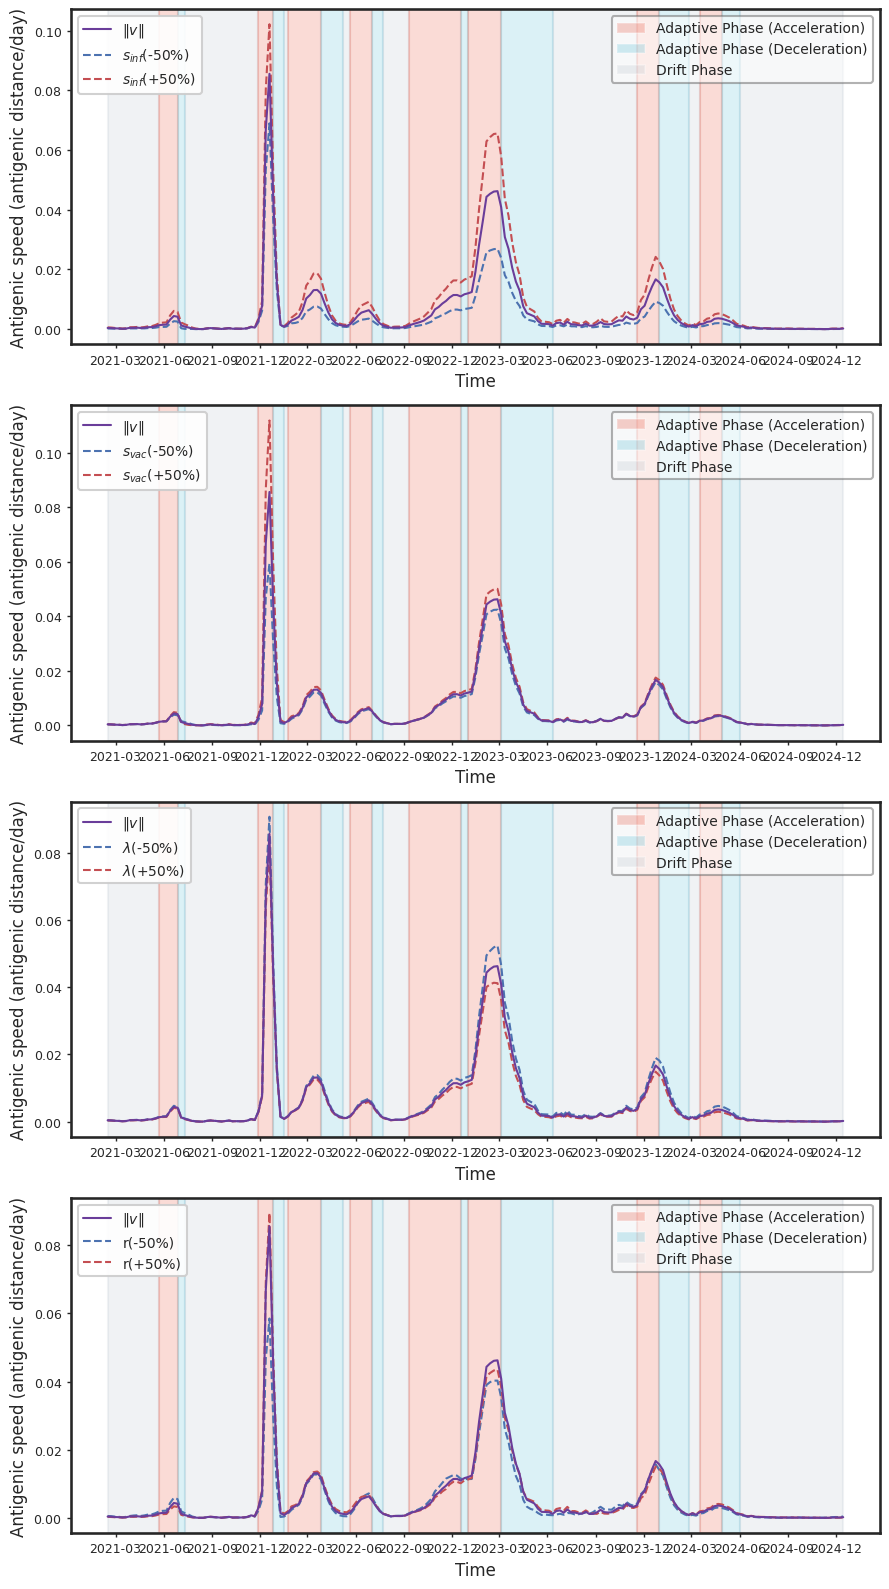

In [28]:
color_minus = "#4C72B0"  
color_plus  = "#C44E52"   
fig, axes = plt.subplots(4,1,figsize=(9, 16), sharex=False)
axes = axes.ravel()
for i in range(4):
    ax1=axes[i]
    l1, = ax1.plot(
        dates_timeline, G_norm_all[:,2*i],
        color=color_minus , linewidth=1.5,
        linestyle="--",
        markersize=2.5, label=group_names[2*i]
    )
    l2, = ax1.plot(
        dates_timeline, G_norm_all[:,2*i+1],
        color=color_plus , linewidth=1.5,linestyle="--",
        markersize=2.5, label=group_names[2*i+1]
    )
    ax1.set_ylabel(r"Antigenic speed (antigenic distance/day)", fontsize=12)
    ax1.set_xlabel('Time', fontsize=12)
    ax1.tick_params(axis='y')
    l3, = ax1.plot(
        dates_timeline, G,
        color=color_model, linewidth=1.5,
        markersize=2.5, label=r"$\|v\|$"
    )
    color_phase_background(ax1, dates_timeline, phase_mask)
    phase_legend = ax1.legend(
        handles=[
            Patch(facecolor=color_acc,   alpha=0.25, label="Adaptive Phase (Acceleration)"),
            Patch(facecolor=color_dec,   alpha=0.25, label="Adaptive Phase (Deceleration)"),
            Patch(facecolor=color_drift, alpha=0.25, label="Drift Phase")
        ],
        loc="upper right",
        frameon=True,
        framealpha=0.5,
        edgecolor='0.4',
        fontsize=10
    )
    ax1.add_artist(phase_legend)
    ax1.legend(
    handles=[l3, l1, l2 ],
    loc="upper left",
    frameon=True,
    framealpha=0.9,
    fontsize=10
    )

    ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))    
    ax1.tick_params(bottom=True, left=True, axis="both", which="major", width=1, length=3.2, labelsize=9)
    ax1.grid(False)
    
plt.tight_layout()

outdir = "./figs"
os.makedirs(outdir, exist_ok=True)
plt.savefig(os.path.join(outdir, "speed_sensitive.pdf"),
            bbox_inches="tight")

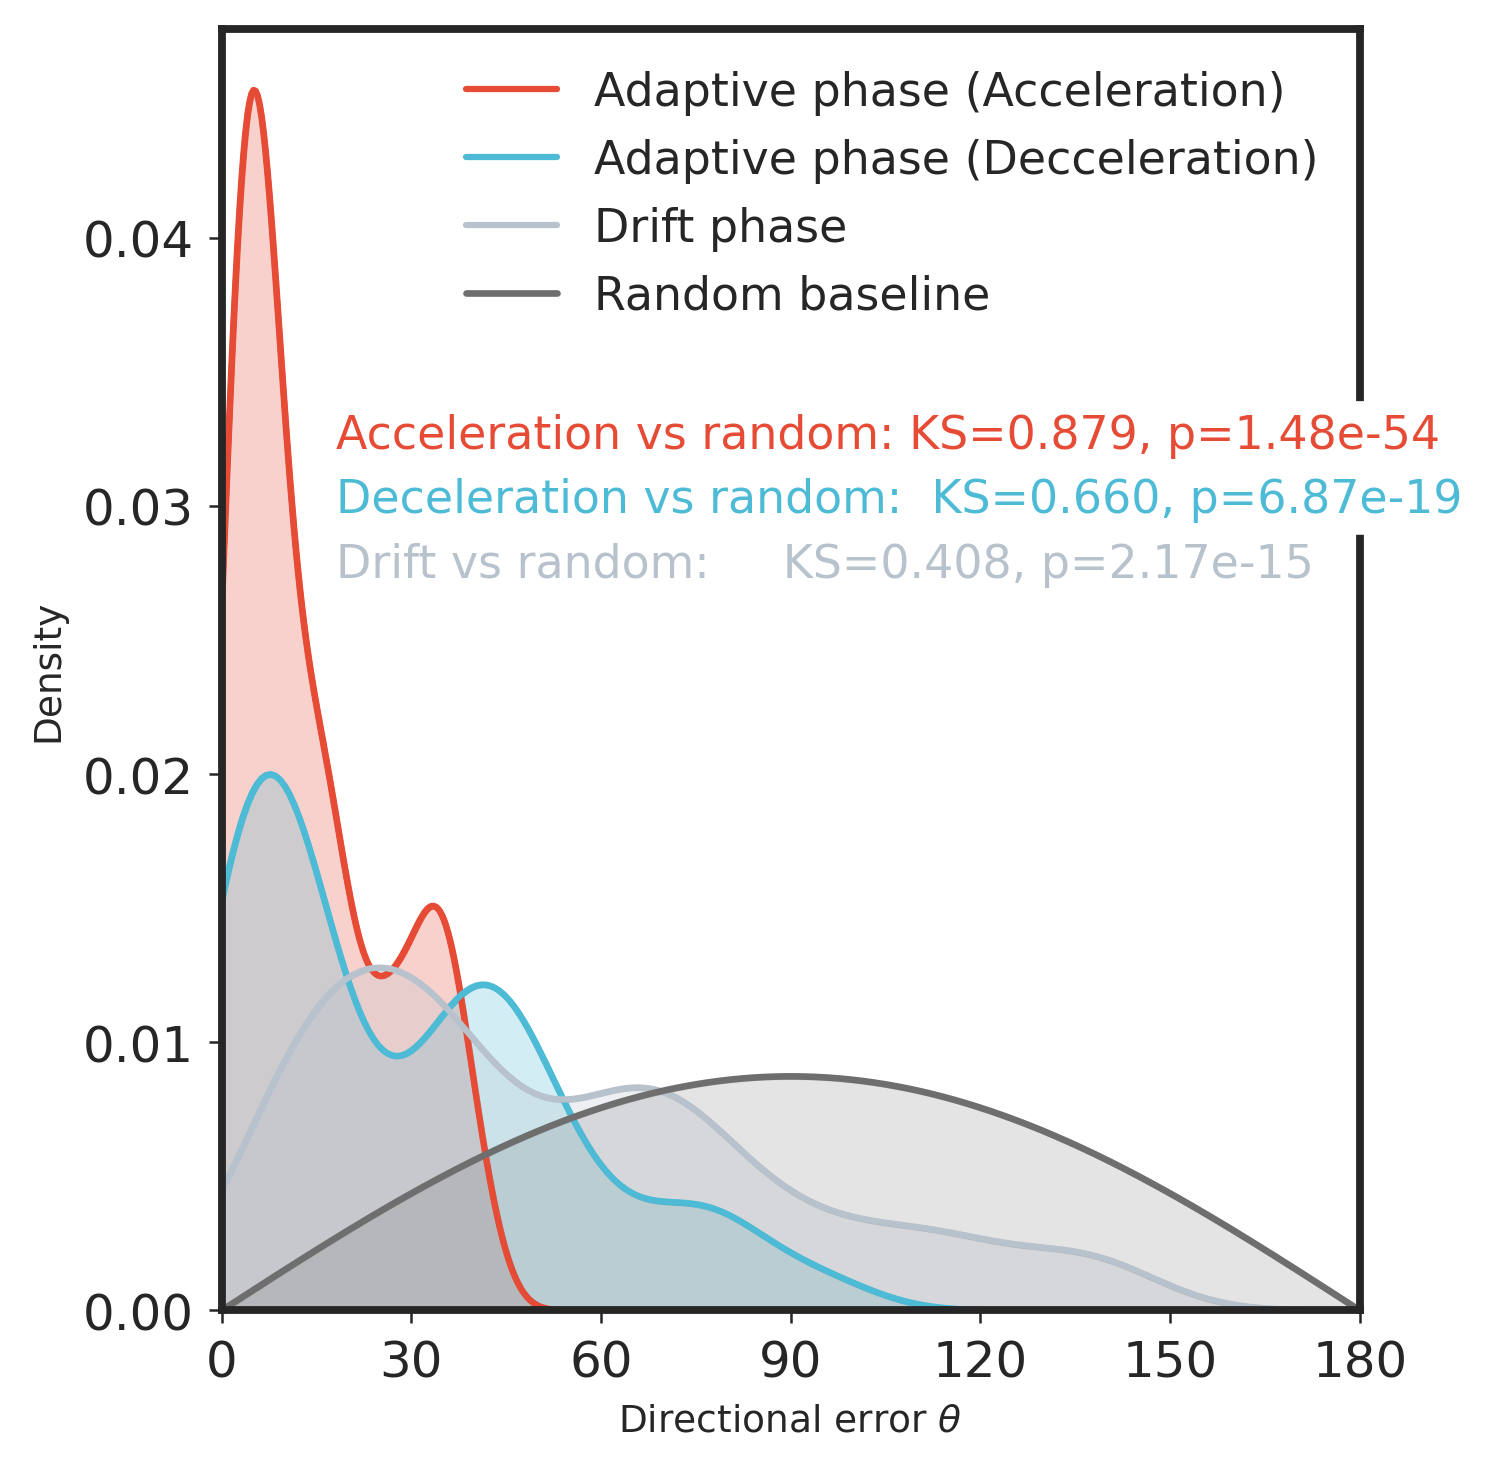

Acceleration: min=1.36°, P5=2.10°, median=9.54°, P95=35.72°, max=40.68°
Deceleration:     min=1.36°, P5=2.57°, median=19.25°, P95=78.41°, max=94.57°
Drift:        min=3.17°, P5=9.59°, median=40.88°, P95=121.74°, max=141.91°


In [29]:
def beta_fn(x, y):
    return gamma(x) * gamma(y) / gamma(x + y)

# ---- random baseline ----
def angle_pdf(theta, dim):
    C = 1.0 / beta_fn(0.5, (dim - 1) / 2.0)
    return C * (np.sin(theta) ** (dim - 2))

def angle_density_per_degree(theta_deg, dim):
    theta = np.deg2rad(theta_deg)
    f_rad = angle_pdf(theta, dim)
    return f_rad * (pi / 180.0)

def angle_cdf(theta, dim, n_pts=2000):
    theta_grid = np.linspace(0, theta, n_pts)
    pdf_vals = angle_pdf(theta_grid, dim)
    cdf_val = np.trapz(pdf_vals, theta_grid)
    return cdf_val

def angle_cdf_vec(theta_array, dim):
    return np.array([angle_cdf(t, dim) for t in theta_array])

a, b = 0, 180
sns.set_style("white")

fig, ax = plt.subplots(figsize=(5,5), dpi=300)
color_uniform = "#6E6E6E"
color_adapt    = "#CC79A7" 
theta_pred=Theta[:,-1]

theta_adp=theta_pred[phase_mask==2]
theta_drf=theta_pred[phase_mask==0 ]
theta_adp_acc=theta_pred[phase_mask==1 ]

bw = 0.75
sns.kdeplot(theta_adp_acc, color=color_acc, lw=1.5, ax=ax, label="Adaptive phase (Acceleration)",bw_adjust=bw)
sns.kdeplot(theta_adp, color=color_dec, lw=1.5, ax=ax, label="Adaptive phase (Decceleration)",bw_adjust=bw)
sns.kdeplot(theta_drf, color=color_drift, lw=1.5, ax=ax, label="Drift phase",bw_adjust=bw)


sns.kdeplot(theta_adp_acc, color=color_acc, fill=True, alpha=0.25, ax=ax,bw_adjust=bw)
sns.kdeplot(theta_adp, color=color_dec, fill=True, alpha=0.25, ax=ax,bw_adjust=bw)
sns.kdeplot(theta_drf, color=color_drift, fill=True, alpha=0.25, ax=ax,bw_adjust=bw)

# --- randome Baseline  ---
theta_deg = np.linspace(a, b, 721)              # 0..180 度
baseline_y = angle_density_per_degree(theta_deg, dim)
ax.plot(theta_deg, baseline_y, color=color_uniform, lw=1.6,
        label=f"Random baseline")
ax.fill_between(theta_deg, 0, baseline_y, color=color_uniform, alpha=0.18)

# --- KS test---
theta_adp_acc_rad = np.deg2rad(theta_adp_acc)
theta_adp_rad = np.deg2rad(theta_adp)
theta_drf_rad = np.deg2rad(theta_drf)
stat_adp, p_adp = kstest(theta_adp_rad , lambda x: angle_cdf_vec(x, dim))
stat_drf, p_drf = kstest(theta_drf_rad , lambda x: angle_cdf_vec(x, dim))
stat_adp_acc,  p_adp_acc  = kstest(theta_adp_acc_rad, lambda x: angle_cdf_vec(x, dim))

ax.text(0.1, 0.7, f"Acceleration vs random: KS={stat_adp_acc:.3f}, p={p_adp_acc:.2e}",
        transform=ax.transAxes, ha="left", va="top", fontsize=11,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=1), color=color_acc)

ax.text(0.1, 0.65, f"Deceleration vs random:  KS={stat_adp:.3f}, p={p_adp:.2e}",
        transform=ax.transAxes, ha="left", va="top", fontsize=11,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=1), color=color_dec)

ax.text(0.1, 0.6, f"Drift vs random:     KS={stat_drf:.3f}, p={p_drf:.2e}",
        transform=ax.transAxes, ha="left", va="top", fontsize=11,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=1), color=color_drift)

# --- median markers (ONLY 3 groups, exclude random baseline) ---
med_adp     = np.median(theta_adp)
med_drf     = np.median(theta_drf)
med_adp_acc = np.median(theta_adp_acc)

ax.set_xlim(a, b)
ax.set_xlabel(r"Directional error $\theta$ ")
ax.set_ylabel("Density")
ax.tick_params(bottom=True, left=True, axis="both", which="major", width=0.6, length=3.2, labelsize=12)
ax.yaxis.grid(True,  linestyle='-', linewidth=0.5)

ax.set_xticks(np.arange(0, 181, 30))
ax.grid(False)
ax.legend(frameon=False, fontsize=11, ncol=1)
plt.tight_layout()
plt.savefig(os.path.join(outdir, "erro_dist.pdf"),
            bbox_inches="tight")
plt.show()

# percentiles (P5, P95)
p5_adp,  p95_adp = np.percentile(theta_adp,     [5, 95])
p5_drf,  p95_drf = np.percentile(theta_drf,     [5, 95])
p5_acc,  p95_acc = np.percentile(theta_adp_acc, [5, 95])

# min / max
mn_adp, mx_adp = np.min(theta_adp),     np.max(theta_adp)
mn_drf, mx_drf = np.min(theta_drf),     np.max(theta_drf)
mn_acc, mx_acc = np.min(theta_adp_acc), np.max(theta_adp_acc)
print(f"Acceleration: min={mn_acc:.2f}°, P5={p5_acc:.2f}°, median={med_adp_acc:.2f}°, P95={p95_acc:.2f}°, max={mx_acc:.2f}°")
print(f"Deceleration:     min={mn_adp:.2f}°, P5={p5_adp:.2f}°, median={med_adp:.2f}°, P95={p95_adp:.2f}°, max={mx_adp:.2f}°")
print(f"Drift:        min={mn_drf:.2f}°, P5={p5_drf:.2f}°, median={med_drf:.2f}°, P95={p95_drf:.2f}°, max={mx_drf:.2f}°")

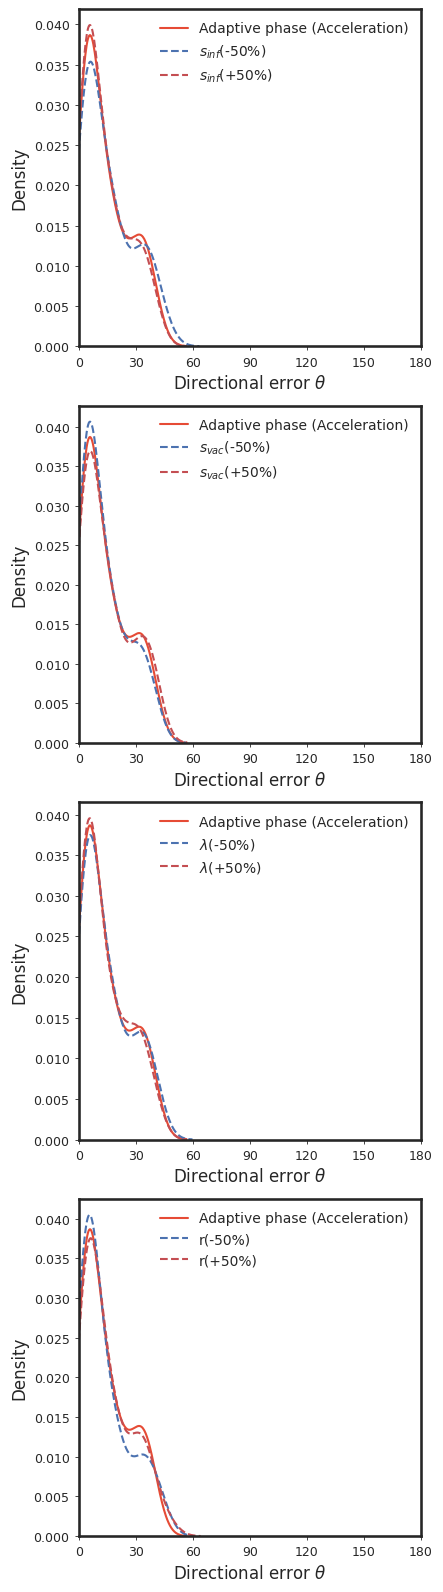

In [30]:
plt.style.use('default')
sns.set_style("white")
sns.set_context("talk", font_scale=0.5)
color_uniform    = "gray"
color_adapt    = "#CC79A7" 
theta_pred=Theta[:,-1]
theta_pred_all=Theta_all

theta_adp_acc=theta_pred[phase_mask==1 ]
theta_adp_acc_all=Theta_all[phase_mask==1,-1,:]

fig, axes = plt.subplots(4,1,figsize=(4.5, 16), sharex=False)
axes = axes.ravel()
for i in range(4):
	ax=axes[i]
	sns.kdeplot(theta_adp_acc, color=color_acc, lw=1.5, ax=ax, label="Adaptive phase (Acceleration)")
	sns.kdeplot(theta_adp_acc_all[:,2*i], color=color_minus, lw=1.5, ax=ax, label=group_names[2*i], linestyle="--")
	sns.kdeplot(theta_adp_acc_all[:,2*i+1], color=color_plus, lw=1.5, ax=ax, label=group_names[2*i+1], linestyle="--")


	ax.set_xlim(a, b)
	ax.set_xlabel(r"Directional error $\theta$ " , fontsize=12)
	ax.set_ylabel("Density", fontsize=12)

	ax.tick_params(bottom=True, left=True, axis="both", which="major", width=0.6, length=3.2, labelsize=9)
	ax.yaxis.grid(True,  linestyle='-', linewidth=0.5)

	ax.set_xticks(np.arange(0, 181, 30))
	ax.grid(False)
	ax.legend(frameon=False, fontsize=10, ncol=1)
	plt.tight_layout()
outdir = "./figs"
os.makedirs(outdir, exist_ok=True)
plt.savefig(os.path.join(outdir, "error_sensitive.pdf"),
            bbox_inches="tight")